# Домашняя работа: Seq2Seq English -> Russian

Ноутбук сделан на основе структуры лекционного `lection_8.ipynb`: сохранены `Lang`, `SOS_token`, `EOS_token`, словари `word2index` / `index2word`, отдельные `EncoderRNN` и `DecoderRNN`, teacher forcing, функции подготовки данных, обучения и greedy-перевода.

В отличие от лекционной демонстрации French-English, здесь используется датасет ManyThings Russian-English, сохраняется кириллица, добавлены `PAD` и `UNK`, а обучение выполняется batch-ами через `Dataset`, `DataLoader` и `collate_fn`.

In [10]:
%matplotlib inline

from io import open
import math
import random
import re
import time
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

from IPython.display import display, Markdown

SEED = 42
FAST_MODE = False

MAX_LENGTH = 12
MAX_PAIRS = 30000
BATCH_SIZE = 64
NUM_EPOCHS = 5
HIDDEN_SIZE = 256
LEARNING_RATE = 0.001
TEACHER_FORCING_RATIO = 0.5
CLIP_NORM = 1.0
EVAL_EXAMPLES = 12
BLEU_EVAL_LIMIT = None

if FAST_MODE:
    MAX_PAIRS = 3000
    BATCH_SIZE = 64
    NUM_EPOCHS = 2
    HIDDEN_SIZE = 128
    BLEU_EVAL_LIMIT = 500


def get_working_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")

    try:
        major, minor = torch.cuda.get_device_capability(0)
        current_arch = f"sm_{major}{minor}"
        supported_arches = torch.cuda.get_arch_list()

        if supported_arches and current_arch not in supported_arches:
            print(
                f"CUDA GPU найден ({torch.cuda.get_device_name(0)}, {current_arch}), "
                f"но текущий PyTorch поддерживает только {supported_arches}. Используем CPU."
            )
            return torch.device("cpu")

        test_tensor = torch.zeros(1, device="cuda")
        del test_tensor
        return torch.device("cuda")
    except Exception as error:
        print(f"CUDA недоступна для этой сборки PyTorch. Используем CPU. Причина: {error}")
        return torch.device("cpu")


device = get_working_device()


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Device:", device)
print(
    f"MAX_LENGTH={MAX_LENGTH}, MAX_PAIRS={MAX_PAIRS}, "
    f"BATCH_SIZE={BATCH_SIZE}, NUM_EPOCHS={NUM_EPOCHS}, HIDDEN_SIZE={HIDDEN_SIZE}"
)

CUDA GPU найден (Tesla P100-PCIE-16GB, sm_60), но текущий PyTorch поддерживает только ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']. Используем CPU.
Device: cpu
MAX_LENGTH=12, MAX_PAIRS=30000, BATCH_SIZE=64, NUM_EPOCHS=5, HIDDEN_SIZE=256


## Загрузка ManyThings Russian-English

Файл `rus-eng.zip` скачивается автоматически, если его ещё нет. В строках ManyThings три поля: английская фраза, русская фраза и attribution. Для обучения используются только первые два поля.

In [11]:
DATA_URL = "https://www.manythings.org/anki/rus-eng.zip"
DATA_DIR = Path("data_manythings")
ARCHIVE_PATH = DATA_DIR / "rus-eng.zip"

DATA_DIR.mkdir(parents=True, exist_ok=True)

def download_with_user_agent(url, destination):
    headers = {
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/124 Safari/537.36",
        "Accept": "application/zip, application/octet-stream, */*",
        "Accept-Language": "en-US,en;q=0.9",
    }
    request = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(request, timeout=60) as response:
        destination.write_bytes(response.read())


if not ARCHIVE_PATH.exists():
    print("Downloading", DATA_URL)
    download_with_user_agent(DATA_URL, ARCHIVE_PATH)
else:
    print("Archive already exists:", ARCHIVE_PATH)

with zipfile.ZipFile(ARCHIVE_PATH, "r") as archive:
    txt_names = [name for name in archive.namelist() if name.lower().endswith(".txt")]
    print("TXT files in archive:", txt_names)
    archive.extractall(DATA_DIR)

txt_files = sorted(DATA_DIR.rglob("*.txt"))
if not txt_files:
    raise FileNotFoundError("TXT file was not found after archive extraction")

preferred = [path for path in txt_files if "rus" in path.name.lower()]
DATA_TXT_PATH = preferred[0] if preferred else txt_files[0]
print("Dataset txt path:", DATA_TXT_PATH)

Archive already exists: data_manythings/rus-eng.zip
TXT files in archive: ['rus.txt', '_about.txt']
Dataset txt path: data_manythings/rus.txt


## Анализ формата данных

Проверим, что каждая строка действительно разбивается по tab и что третья колонка является служебной attribution-информацией, а не частью перевода.

In [12]:
raw_lines = DATA_TXT_PATH.read_text(encoding="utf-8").splitlines()
print("Всего строк в txt:", len(raw_lines))

for line in raw_lines[:5]:
    parts = line.split("\t")
    print("-" * 80)
    print("Колонок:", len(parts))
    print("English:", parts[0] if len(parts) > 0 else "")
    print("Russian:", parts[1] if len(parts) > 1 else "")
    print("Attribution:", parts[2][:90] if len(parts) > 2 else "")

Всего строк в txt: 536124
--------------------------------------------------------------------------------
Колонок: 3
English: Go.
Russian: Марш!
Attribution: CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #1159202 (shanghainese)
--------------------------------------------------------------------------------
Колонок: 3
English: Go.
Russian: Иди.
Attribution: CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #5898247 (marafon)
--------------------------------------------------------------------------------
Колонок: 3
English: Go.
Russian: Идите.
Attribution: CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #5898250 (marafon)
--------------------------------------------------------------------------------
Колонок: 3
English: Hi.
Russian: Здравствуйте.
Attribution: CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #402127 (odexed)
--------------------------------------------------------------------------------
Колонок: 3
English: Hi.
Russian: Пр

## Нормализация English и Russian

В лекции использовалась `unicodeToAscii()` и фильтр `[^a-zA-Z.!?]`. Для русского языка это нельзя применять, потому что кириллица будет удалена. Поэтому используются две отдельные функции нормализации.

In [13]:
def normalize_english(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1 ", s)
    s = re.sub(r"[^a-z.!?]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def normalize_russian(s):
    s = s.lower().strip()
    s = re.sub(r"([.!?])", r" \1 ", s)
    s = re.sub(r"[^а-яё.!?]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


for en, ru in [
    ("I am home.", "Я дома."),
    ("Do you understand me?", "Ты меня понимаешь?"),
    ("He is a very good person.", "Он очень хороший человек."),
]:
    print("EN:", normalize_english(en))
    print("RU:", normalize_russian(ru))
    print()

EN: i am home .
RU: я дома .

EN: do you understand me ?
RU: ты меня понимаешь ?

EN: he is a very good person .
RU: он очень хороший человек .



## Формирование train / validation / test

Фильтр из лекции `eng_prefixes` здесь не используется, потому что он был специфичен для демонстрационного French-English tutorial. Оставляем короткие пары, перемешиваем их фиксированным seed и делим один раз на train / validation / test. Этот split будет общим для всех трёх архитектур.

In [14]:
def read_manythings_pairs(path):
    pairs = []
    skipped = 0

    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2:
            skipped += 1
            continue

        english = normalize_english(parts[0])
        russian = normalize_russian(parts[1])

        if not english or not russian:
            skipped += 1
            continue

        if len(english.split()) <= MAX_LENGTH and len(russian.split()) <= MAX_LENGTH:
            pairs.append([english, russian])

    return pairs, skipped


all_pairs, skipped_lines = read_manythings_pairs(DATA_TXT_PATH)
print("Пропущено строк:", skipped_lines)
print("Пар после нормализации и фильтрации длины:", len(all_pairs))

shuffle_rng = random.Random(SEED)
shuffle_rng.shuffle(all_pairs)
pairs = all_pairs[:MAX_PAIRS]

train_end = int(0.8 * len(pairs))
val_end = int(0.9 * len(pairs))
train_pairs = pairs[:train_end]
val_pairs = pairs[train_end:val_end]
test_pairs = pairs[val_end:]

print("Используется пар:", len(pairs))
print("Train:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Test:", len(test_pairs))

print("\nПроверка, что кириллица сохранена:")
for en, ru in train_pairs[:5]:
    print("EN:", en)
    print("RU:", ru)
    print()

Пропущено строк: 0
Пар после нормализации и фильтрации длины: 519092
Используется пар: 30000
Train: 24000
Validation: 3000
Test: 3000

Проверка, что кириллица сохранена:
EN: tom went inside the house .
RU: том вошёл в дом .

EN: we want a better life .
RU: мы хотим лучшей жизни .

EN: tom is available .
RU: том доступен .

EN: i despised you .
RU: я презирал тебя .

EN: everyone in my family enjoys watching tv .
RU: все в нашей семье любят смотреть телевизор .



## Lang и словари

Словари строятся только по train dataset, чтобы не обучаться на validation/test. Для незнакомых слов используется `UNK_token`, поэтому validation/test не вызывают `KeyError`.

In [15]:
SOS_token = 0
EOS_token = 1
PAD_token = 2
UNK_token = 3

SPECIAL_TOKENS = {
    SOS_token: "SOS",
    EOS_token: "EOS",
    PAD_token: "PAD",
    UNK_token: "UNK",
}


class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {
            "SOS": SOS_token,
            "EOS": EOS_token,
            "PAD": PAD_token,
            "UNK": UNK_token,
        }
        self.word2count = {}
        self.index2word = dict(SPECIAL_TOKENS)
        self.n_words = 4

    def addSentence(self, sentence):
        for word in sentence.split(" "):
            self.addWord(word)

    def addWord(self, word):
        if not word:
            return
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        elif word not in {"SOS", "EOS", "PAD", "UNK"}:
            self.word2count[word] += 1


input_lang = Lang("eng")
output_lang = Lang("rus")

for en, ru in train_pairs:
    input_lang.addSentence(en)
    output_lang.addSentence(ru)

print("Counted words:")
print(input_lang.name, input_lang.n_words)
print(output_lang.name, output_lang.n_words)
print("UNK check:", input_lang.word2index.get("__not_in_vocab__", UNK_token))


def indexesFromSentence(lang, sentence):
    return [lang.word2index.get(word, UNK_token) for word in sentence.split(" ") if word]


def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long)


def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return input_tensor, target_tensor

Counted words:
eng 5811
rus 13860
UNK check: 3


## Dataset / DataLoader / batching

В лекции обучение шло по одной паре предложений. Здесь batch формируется через `Dataset`, `DataLoader` и `collate_fn`: предложения превращаются в индексы, к ним добавляется `EOS`, затем batch дополняется `PAD` до максимальной длины внутри batch.

In [16]:
class TranslationDataset(Dataset):
    def __init__(self, sentence_pairs):
        self.sentence_pairs = sentence_pairs

    def __len__(self):
        return len(self.sentence_pairs)

    def __getitem__(self, idx):
        return self.sentence_pairs[idx]


def make_collate_fn(input_lang, output_lang):
    def collate_fn(batch):
        input_tensors = [tensorFromSentence(input_lang, en) for en, _ in batch]
        target_tensors = [tensorFromSentence(output_lang, ru) for _, ru in batch]

        encoder_input = pad_sequence(
            input_tensors,
            batch_first=True,
            padding_value=PAD_token,
        )
        target = pad_sequence(
            target_tensors,
            batch_first=True,
            padding_value=PAD_token,
        )
        return encoder_input, target

    return collate_fn


collate_fn = make_collate_fn(input_lang, output_lang)


def make_loaders(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        TranslationDataset(train_pairs),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
        generator=generator,
    )
    val_loader = DataLoader(
        TranslationDataset(val_pairs),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )
    test_loader = DataLoader(
        TranslationDataset(test_pairs),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = make_loaders(SEED)
encoder_input_batch, target_batch = next(iter(train_loader))

print("encoder_input shape:", tuple(encoder_input_batch.shape))
print("target shape:", tuple(target_batch.shape))
print("encoder_input пример:", encoder_input_batch[0].tolist())
print("target пример:", target_batch[0].tolist())

encoder_input shape: (64, 12)
target shape: (64, 13)
encoder_input пример: [451, 19, 1811, 38, 35, 36, 55, 1, 2, 2, 2, 2]
target пример: [148, 31, 1312, 47, 1, 2, 2, 2, 2, 2, 2, 2, 2]


## Короткое теоретическое объяснение

### Seq2Seq

Encoder читает английское предложение и формирует скрытое состояние. Decoder получает это состояние и последовательно генерирует русский перевод.

```text
English sentence
      |
   Encoder
      |
 hidden state
      |
   Decoder
      |
Russian sentence
```

### GRU

GRU использует gated hidden state и проще LSTM: состояние одно, без отдельной cell memory.

### LSTM

LSTM использует два состояния: hidden state `h` и cell state `c`. Это делает ячейку более гибкой, но увеличивает число параметров и вычислительную стоимость.

### Два recurrent layers

В двухслойной модели output первого recurrent layer становится входом второго recurrent layer. Модель получает большую глубину и больше параметров, но это не гарантирует улучшение качества на любом датасете.

## Encoder и Decoder

Архитектура остаётся классической, как в лекции: `Embedding -> GRU/LSTM Encoder -> hidden state -> GRU/LSTM Decoder -> Linear`. Attention, Transformer, pretrained-модели и beam search не используются.

In [17]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, rnn_type="GRU"):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type.upper()

        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        rnn_cls = self._get_rnn_class()
        self.rnn = rnn_cls(
            hidden_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

    def _get_rnn_class(self):
        if self.rnn_type == "GRU":
            return nn.GRU
        if self.rnn_type == "LSTM":
            return nn.LSTM
        raise ValueError("rnn_type must be 'GRU' or 'LSTM'")

    def forward(self, input_batch):
        embedded = self.embedding(input_batch)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden


class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, num_layers=1, rnn_type="GRU"):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type.upper()

        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        rnn_cls = self._get_rnn_class()
        self.rnn = rnn_cls(
            hidden_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.out = nn.Linear(hidden_size, output_size)

    def _get_rnn_class(self):
        if self.rnn_type == "GRU":
            return nn.GRU
        if self.rnn_type == "LSTM":
            return nn.LSTM
        raise ValueError("rnn_type must be 'GRU' or 'LSTM'")

    def forward(self, input_tokens, hidden):
        embedded = self.embedding(input_tokens).unsqueeze(1)
        output = F.relu(embedded)
        output, hidden = self.rnn(output, hidden)
        logits = self.out(output.squeeze(1))
        return logits, hidden


def count_parameters(encoder, decoder):
    return sum(
        p.numel()
        for p in list(encoder.parameters()) + list(decoder.parameters())
    )

## Проверка shapes

Диагностическая ячейка показывает реальные batch-размеры, encoder output, hidden state и decoder output. Для LSTM отдельно выводятся `h` и `c`.

In [18]:
def print_hidden_shape(hidden):
    if isinstance(hidden, tuple):
        h, c = hidden
        print("encoder hidden h shape:", tuple(h.shape))
        print("encoder hidden c shape:", tuple(c.shape))
    else:
        print("encoder hidden shape:", tuple(hidden.shape))


def diagnostic_shapes(rnn_type, num_layers):
    encoder = EncoderRNN(
        input_lang.n_words,
        HIDDEN_SIZE,
        num_layers=num_layers,
        rnn_type=rnn_type,
    ).to(device)
    decoder = DecoderRNN(
        HIDDEN_SIZE,
        output_lang.n_words,
        num_layers=num_layers,
        rnn_type=rnn_type,
    ).to(device)

    sample_input = encoder_input_batch.to(device)
    batch_size = sample_input.size(0)

    encoder_outputs, encoder_hidden = encoder(sample_input)
    decoder_input = torch.full(
        (batch_size,),
        SOS_token,
        dtype=torch.long,
        device=device,
    )
    decoder_logits, decoder_hidden = decoder(decoder_input, encoder_hidden)

    print(f"\n{rnn_type}, num_layers={num_layers}")
    print("encoder input shape:", tuple(sample_input.shape))
    print("target shape:", tuple(target_batch.shape))
    print("encoder output shape:", tuple(encoder_outputs.shape))
    print_hidden_shape(encoder_hidden)
    print("decoder output shape:", tuple(decoder_logits.shape))


diagnostic_shapes("GRU", 2)
diagnostic_shapes("LSTM", 1)


GRU, num_layers=2
encoder input shape: (64, 12)
target shape: (64, 13)
encoder output shape: (64, 12, 256)
encoder hidden shape: (2, 64, 256)
decoder output shape: (64, 13860)

LSTM, num_layers=1
encoder input shape: (64, 12)
target shape: (64, 13)
encoder output shape: (64, 12, 256)
encoder hidden h shape: (1, 64, 256)
encoder hidden c shape: (1, 64, 256)
decoder output shape: (64, 13860)


## Функции train / validation

`CrossEntropyLoss(ignore_index=PAD_token)` исключает padding из loss. На validation и test decoder работает autoregressive: следующий вход берётся из собственного prediction, а не из правильного target.

In [19]:
def asMinutes(seconds):
    minutes = math.floor(seconds / 60)
    seconds -= minutes * 60
    return f"{minutes}m {int(seconds)}s"


def count_non_pad_tokens(target_tensor):
    return int((target_tensor != PAD_token).sum().item())


def train_batch(
    input_tensor,
    target_tensor,
    encoder,
    decoder,
    encoder_optimizer,
    decoder_optimizer,
    criterion,
):
    encoder.train()
    decoder.train()

    input_tensor = input_tensor.to(device)
    target_tensor = target_tensor.to(device)

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    batch_size = input_tensor.size(0)
    target_length = target_tensor.size(1)

    encoder_outputs, encoder_hidden = encoder(input_tensor)

    decoder_input = torch.full(
        (batch_size,),
        SOS_token,
        dtype=torch.long,
        device=device,
    )
    decoder_hidden = encoder_hidden
    logits_by_step = []

    for timestep in range(target_length):
        decoder_logits, decoder_hidden = decoder(decoder_input, decoder_hidden)
        logits_by_step.append(decoder_logits.unsqueeze(1))

        top_tokens = decoder_logits.argmax(dim=1).detach()
        use_teacher_forcing = random.random() < TEACHER_FORCING_RATIO
        decoder_input = target_tensor[:, timestep] if use_teacher_forcing else top_tokens

    logits = torch.cat(logits_by_step, dim=1)
    loss = criterion(
        logits.reshape(-1, logits.size(-1)),
        target_tensor.reshape(-1),
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=CLIP_NORM)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=CLIP_NORM)
    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item(), count_non_pad_tokens(target_tensor)


def evaluate_loss(data_loader, encoder, decoder, criterion):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for input_tensor, target_tensor in data_loader:
            input_tensor = input_tensor.to(device)
            target_tensor = target_tensor.to(device)

            batch_size = input_tensor.size(0)
            target_length = target_tensor.size(1)

            encoder_outputs, encoder_hidden = encoder(input_tensor)
            decoder_input = torch.full(
                (batch_size,),
                SOS_token,
                dtype=torch.long,
                device=device,
            )
            decoder_hidden = encoder_hidden
            logits_by_step = []

            for timestep in range(target_length):
                decoder_logits, decoder_hidden = decoder(decoder_input, decoder_hidden)
                logits_by_step.append(decoder_logits.unsqueeze(1))
                decoder_input = decoder_logits.argmax(dim=1).detach()

            logits = torch.cat(logits_by_step, dim=1)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_tensor.reshape(-1),
            )
            tokens = count_non_pad_tokens(target_tensor)
            total_loss += loss.item() * tokens
            total_tokens += tokens

    return total_loss / max(total_tokens, 1)


def train_model(encoder, decoder, train_loader, val_loader, num_epochs=NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=LEARNING_RATE)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=LEARNING_RATE)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, num_epochs + 1):
        epoch_loss = 0.0
        epoch_tokens = 0
        epoch_start = time.time()

        for input_tensor, target_tensor in train_loader:
            batch_loss, tokens = train_batch(
                input_tensor,
                target_tensor,
                encoder,
                decoder,
                encoder_optimizer,
                decoder_optimizer,
                criterion,
            )
            epoch_loss += batch_loss * tokens
            epoch_tokens += tokens

        train_loss = epoch_loss / max(epoch_tokens, 1)
        val_loss = evaluate_loss(val_loader, encoder, decoder, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"time: {asMinutes(time.time() - epoch_start)}"
        )

    return history

## Функция перевода и метрики

Для inference используется greedy decoding: после `SOS` каждый следующий токен берётся через `argmax`. Правильный русский target в decoder не подаётся. BLEU считается на уровне корпуса с modified n-gram precision, brevity penalty и небольшим smoothing.

In [20]:
def translate(encoder, decoder, sentence, max_length=MAX_LENGTH):
    encoder.eval()
    decoder.eval()

    normalized_sentence = normalize_english(sentence)
    input_tensor = tensorFromSentence(input_lang, normalized_sentence).unsqueeze(0).to(device)
    decoded_words = []

    with torch.no_grad():
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_input = torch.tensor([SOS_token], dtype=torch.long, device=device)
        decoder_hidden = encoder_hidden

        for _ in range(max_length):
            decoder_logits, decoder_hidden = decoder(decoder_input, decoder_hidden)
            next_token = int(decoder_logits.argmax(dim=1).item())

            if next_token == EOS_token:
                break

            word = output_lang.index2word.get(next_token, "UNK")
            if next_token not in {SOS_token, PAD_token}:
                decoded_words.append(word)

            decoder_input = torch.tensor([next_token], dtype=torch.long, device=device)

    return " ".join(decoded_words)


def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def corpus_bleu(references, predictions, max_n=4, smooth=1.0):
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    reference_length = 0
    prediction_length = 0

    for reference, prediction in zip(references, predictions):
        ref_tokens = reference.split()
        pred_tokens = prediction.split()
        reference_length += len(ref_tokens)
        prediction_length += len(pred_tokens)

        for n in range(1, max_n + 1):
            pred_ngrams = ngram_counts(pred_tokens, n)
            ref_ngrams = ngram_counts(ref_tokens, n)
            clipped_counts[n - 1] += sum(
                min(count, ref_ngrams[ngram])
                for ngram, count in pred_ngrams.items()
            )
            total_counts[n - 1] += max(len(pred_tokens) - n + 1, 0)

    if prediction_length == 0:
        return 0.0

    precisions = [
        (clipped_counts[i] + smooth) / (total_counts[i] + smooth)
        for i in range(max_n)
    ]
    log_precision = sum(math.log(p) for p in precisions) / max_n
    brevity_penalty = 1.0
    if prediction_length < reference_length:
        brevity_penalty = math.exp(1 - reference_length / max(prediction_length, 1))

    return 100.0 * brevity_penalty * math.exp(log_precision)


def evaluate_translation_quality(encoder, decoder, sentence_pairs, limit=BLEU_EVAL_LIMIT):
    if limit is not None and len(sentence_pairs) > limit:
        eval_pairs = random.Random(SEED).sample(sentence_pairs, limit)
    else:
        eval_pairs = sentence_pairs

    references = []
    predictions = []

    for english, russian in eval_pairs:
        prediction = translate(encoder, decoder, english)
        references.append(russian)
        predictions.append(prediction)

    bleu = corpus_bleu(references, predictions)
    exact_match = float(np.mean([pred == ref for pred, ref in zip(predictions, references)]))

    return {
        "BLEU": bleu,
        "Exact match": exact_match,
        "Evaluated translations": len(eval_pairs),
    }

## Запуск экспериментов

Все три эксперимента используют один и тот же датасет, один split, одинаковые основные гиперпараметры, optimizer и число эпох.

In [21]:
EXPERIMENTS = [
    {
        "display_name": "GRU 1 layer",
        "table_model": "GRU baseline",
        "rnn_type": "GRU",
        "num_layers": 1,
    },
    {
        "display_name": "GRU 2 layers",
        "table_model": "GRU 2 layers",
        "rnn_type": "GRU",
        "num_layers": 2,
    },
    {
        "display_name": "LSTM 1 layer",
        "table_model": "LSTM",
        "rnn_type": "LSTM",
        "num_layers": 1,
    },
]


def run_experiment(display_name, table_model, rnn_type, num_layers):
    print("=" * 90)
    print(f"Experiment: {display_name} | cell={rnn_type} | layers={num_layers}")

    set_seed(SEED)
    train_loader, val_loader, test_loader = make_loaders(SEED)

    encoder = EncoderRNN(
        input_lang.n_words,
        HIDDEN_SIZE,
        num_layers=num_layers,
        rnn_type=rnn_type,
    ).to(device)
    decoder = DecoderRNN(
        HIDDEN_SIZE,
        output_lang.n_words,
        num_layers=num_layers,
        rnn_type=rnn_type,
    ).to(device)

    parameters = count_parameters(encoder, decoder)
    print("Parameters:", parameters)

    start = time.time()
    history = train_model(encoder, decoder, train_loader, val_loader, NUM_EPOCHS)
    train_time = time.time() - start

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    test_loss = evaluate_loss(test_loader, encoder, decoder, criterion)
    translation_metrics = evaluate_translation_quality(encoder, decoder, test_pairs)

    metrics = {
        "Model": table_model,
        "Cell": rnn_type,
        "Layers": num_layers,
        "Best val loss": min(history["val_loss"]),
        "Test loss": test_loss,
        "BLEU": translation_metrics["BLEU"],
        "Exact match": translation_metrics["Exact match"],
        "Train time": train_time,
        "Parameters": parameters,
        "Evaluated translations": translation_metrics["Evaluated translations"],
    }

    print(
        f"Done {display_name}: test loss={test_loss:.4f}, "
        f"BLEU={metrics['BLEU']:.2f}, exact={metrics['Exact match']:.4f}, "
        f"time={asMinutes(train_time)}"
    )

    return {
        "encoder": encoder,
        "decoder": decoder,
        "history": history,
        "metrics": metrics,
    }

In [22]:
experiments_output = {}

for config in EXPERIMENTS:
    output = run_experiment(**config)
    experiments_output[config["display_name"]] = output

Experiment: GRU 1 layer | cell=GRU | layers=1
Parameters: 9387300
Epoch 01/5 | train loss: 5.1786 | val loss: 4.8570 | time: 2m 11s
Epoch 02/5 | train loss: 4.2003 | val loss: 4.4600 | time: 2m 9s
Epoch 03/5 | train loss: 3.6418 | val loss: 4.2359 | time: 2m 7s
Epoch 04/5 | train loss: 3.2018 | val loss: 4.0911 | time: 2m 8s
Epoch 05/5 | train loss: 2.8032 | val loss: 4.0417 | time: 2m 8s
Done GRU 1 layer: test loss=3.9735, BLEU=6.71, exact=0.0003, time=10m 49s
Experiment: GRU 2 layers | cell=GRU | layers=2
Parameters: 10176804
Epoch 01/5 | train loss: 5.2413 | val loss: 4.8906 | time: 2m 13s
Epoch 02/5 | train loss: 4.2194 | val loss: 4.3655 | time: 2m 14s
Epoch 03/5 | train loss: 3.6123 | val loss: 4.1021 | time: 2m 15s
Epoch 04/5 | train loss: 3.1208 | val loss: 3.9380 | time: 2m 18s
Epoch 05/5 | train loss: 2.6729 | val loss: 3.8602 | time: 2m 17s
Done GRU 2 layers: test loss=3.8146, BLEU=8.10, exact=0.0007, time=11m 19s
Experiment: LSTM 1 layer | cell=LSTM | layers=1
Parameters: 9

## Графики loss

Training loss и validation loss строятся на отдельных графиках для прямого сравнения трёх моделей.

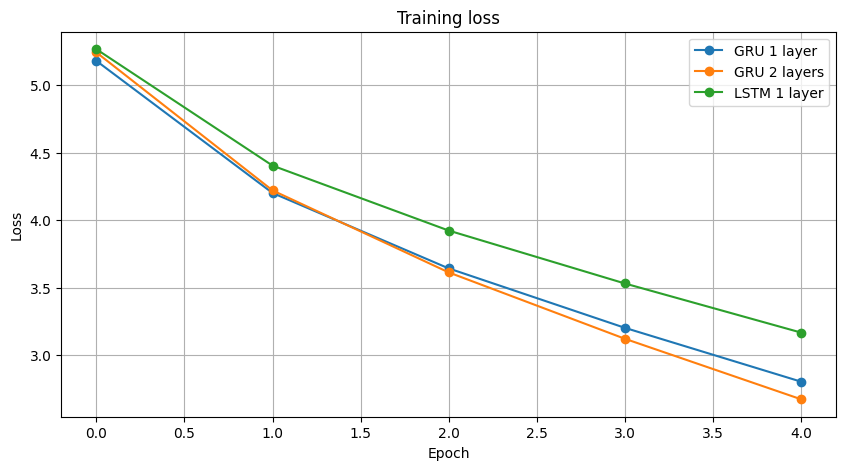

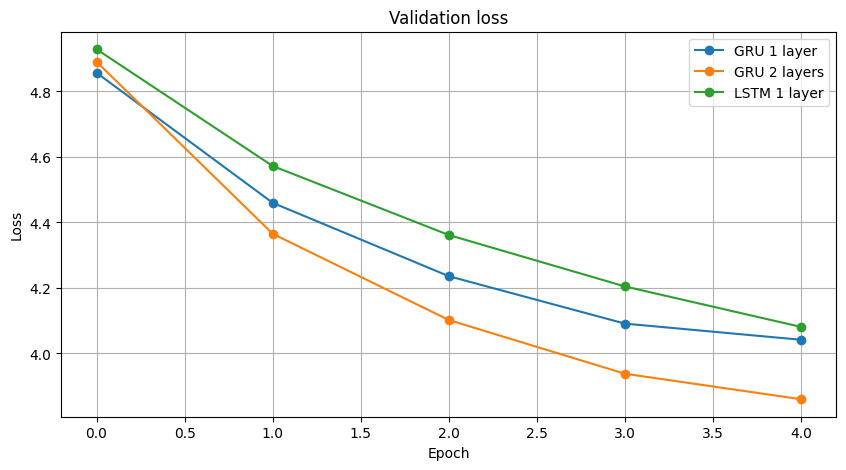

In [23]:
plt.figure(figsize=(10, 5))
for name, output in experiments_output.items():
    plt.plot(output["history"]["train_loss"], marker="o", label=name)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for name, output in experiments_output.items():
    plt.plot(output["history"]["val_loss"], marker="o", label=name)
plt.title("Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

## Сравнительная таблица

Значения в таблице рассчитываются программно после фактического обучения моделей.

In [24]:
results_df = pd.DataFrame(
    [output["metrics"] for output in experiments_output.values()]
)

ordered_columns = [
    "Model",
    "Cell",
    "Layers",
    "Best val loss",
    "Test loss",
    "BLEU",
    "Exact match",
    "Train time",
    "Parameters",
    "Evaluated translations",
]
results_df = results_df[ordered_columns]

styled_results = results_df.style.format({
    "Best val loss": "{:.4f}",
    "Test loss": "{:.4f}",
    "BLEU": "{:.2f}",
    "Exact match": "{:.4f}",
    "Train time": "{:.1f}",
    "Parameters": "{:,}",
})

display(styled_results)

,Model,Cell,Layers,Best val loss,Test loss,BLEU,Exact match,Train time,Parameters,Evaluated translations
0,GRU baseline,GRU,1,4.0417,3.9735,6.71,0.0003,649.5,"9,387,300",3000
1,GRU 2 layers,GRU,2,3.8602,3.8146,8.10,0.0007,679.5,"10,176,804",3000
2,LSTM,LSTM,1,4.0810,4.0069,6.94,0.0000,653.6,"9,650,468",3000


## Примеры переводов

Для всех моделей используются одни и те же случайные test-предложения с фиксированным seed. Примеры не подбираются вручную.

In [25]:
example_rng = random.Random(SEED)
example_pairs = example_rng.sample(test_pairs, min(EVAL_EXAMPLES, len(test_pairs)))

for english, reference in example_pairs:
    print("=" * 90)
    print("English:")
    print(english)
    print("\nReference:")
    print(reference)

    for name, output in experiments_output.items():
        prediction = translate(output["encoder"], output["decoder"], english)
        print(f"\n{name}:")
        print(prediction)

    print()

English:
i hope that that s not true .

Reference:
надеюсь это неправда .

GRU 1 layer:
надеюсь не не так уж так . .

GRU 2 layers:
надеюсь что не так . .

LSTM 1 layer:
надеюсь это не не .

English:
tom told me he had been sick .

Reference:
том сказал мне что был болен .

GRU 1 layer:
том сказал мне что он мне мне .

GRU 2 layers:
том сказал мне что ему нужно .

LSTM 1 layer:
том сказал мне что мне меня . .

English:
i m going to tell tom what happened .

Reference:
я собираюсь рассказать тому что произошло .

GRU 1 layer:
я я сказать тому что том .

GRU 2 layers:
я собираюсь тому тому что что случилось .

LSTM 1 layer:
я я что том что том .

English:
how did you do that ?

Reference:
как ты это сделал ?

GRU 1 layer:
как ты думаешь это сделать это сделать ?

GRU 2 layers:
как ты это это сделал ?

LSTM 1 layer:
как ты это это ?

English:
tom didn t know who it was .

Reference:
том не знал кто это .

GRU 1 layer:
не не том знает кто это это .

GRU 2 layers:
том не знал что это это .


# Выводы

Следующая ячейка формирует итоговый анализ на основе фактически полученной таблицы результатов.

In [26]:
def delta_text(value, metric_name, lower_is_better=False):
    if abs(value) < 1e-9:
        return f"{metric_name} не изменился"
    if lower_is_better:
        direction = "улучшился" if value < 0 else "ухудшился"
    else:
        direction = "улучшился" if value > 0 else "ухудшился"
    return f"{metric_name} {direction} на {abs(value):.4f}"


def percent_change(new, old):
    if old == 0:
        return float("nan")
    return 100.0 * (new - old) / old


df = results_df.copy()
grub = df[df["Model"] == "GRU baseline"].iloc[0]
gru2 = df[df["Model"] == "GRU 2 layers"].iloc[0]
lstm = df[df["Model"] == "LSTM"].iloc[0]

best_bleu = df.loc[df["BLEU"].idxmax()]
fastest = df.loc[df["Train time"].idxmin()]

bleu_gap = df["BLEU"].max() - df["BLEU"]
compromise_pool = df[bleu_gap <= 1.0]
if len(compromise_pool) == 0:
    compromise_pool = df
best_compromise = compromise_pool.sort_values(["Train time", "Test loss"]).iloc[0]

gru2_bleu_delta = gru2["BLEU"] - grub["BLEU"]
gru2_val_delta = gru2["Best val loss"] - grub["Best val loss"]
gru2_time_pct = percent_change(gru2["Train time"], grub["Train time"])
gru2_params_pct = percent_change(gru2["Parameters"], grub["Parameters"])

lstm_bleu_delta = lstm["BLEU"] - grub["BLEU"]
lstm_val_delta = lstm["Best val loss"] - grub["Best val loss"]
lstm_time_pct = percent_change(lstm["Train time"], grub["Train time"])
lstm_params_pct = percent_change(lstm["Parameters"], grub["Parameters"])

if gru2_bleu_delta > 0 and gru2_val_delta <= 0:
    layer_meaning = "дополнительный GRU-слой дал признаки полезного улучшения"
elif gru2_bleu_delta > 0 or gru2_val_delta <= 0:
    layer_meaning = "дополнительный GRU-слой дал смешанный эффект"
else:
    layer_meaning = "убедимой пользы от дополнительного GRU-слоя на этих настройках не видно"

if lstm_bleu_delta > 0 and lstm_val_delta <= 0:
    lstm_meaning = "LSTM дала преимущество над базовым GRU"
elif lstm_bleu_delta > 0 or lstm_val_delta <= 0:
    lstm_meaning = "LSTM дала смешанный результат относительно базового GRU"
else:
    lstm_meaning = "LSTM не дала преимущества над базовым GRU на этих настройках"

conclusion = f'''
1. Базовый однослойный GRU получил test loss `{grub['Test loss']:.4f}`, BLEU `{grub['BLEU']:.2f}` и exact match `{grub['Exact match']:.4f}`.
2. После добавления второго GRU-слоя: {delta_text(gru2_bleu_delta, 'BLEU')}; {delta_text(gru2_val_delta, 'best validation loss', lower_is_better=True)}.
3. BLEU у GRU с двумя слоями относительно baseline изменился на `{gru2_bleu_delta:+.2f}`.
4. Best validation loss у GRU с двумя слоями относительно baseline изменился на `{gru2_val_delta:+.4f}`.
5. Время обучения GRU с двумя слоями изменилось на `{gru2_time_pct:+.1f}%` относительно baseline.
6. Число параметров GRU с двумя слоями изменилось на `{gru2_params_pct:+.1f}%` относительно baseline.
7. LSTM относительно базового GRU: {delta_text(lstm_bleu_delta, 'BLEU')}; {delta_text(lstm_val_delta, 'best validation loss', lower_is_better=True)}. Время изменилось на `{lstm_time_pct:+.1f}%`, параметры на `{lstm_params_pct:+.1f}%`.
8. Лучший BLEU показала модель `{best_bleu['Model']}` со значением `{best_bleu['BLEU']:.2f}`.
9. Быстрее всего обучалась модель `{fastest['Model']}`: `{asMinutes(float(fastest['Train time']))}`.
10. По сравнению GRU baseline и GRU 2 layers: {layer_meaning}.
11. По сравнению LSTM и GRU baseline: {lstm_meaning}.
12. Лучший компромисс по правилу "BLEU не дальше 1.0 пункта от лучшего результата и минимальное время" - `{best_compromise['Model']}`.
13. Ограничение простой Seq2Seq без attention в том, что всё входное предложение сжимается в одно скрытое состояние. На более длинных фразах и при большом словаре такая модель часто теряет детали, хуже работает с порядком слов и уступает attention/Transformer-подходам.
'''

display(Markdown(conclusion))


1. Базовый однослойный GRU получил test loss `3.9735`, BLEU `6.71` и exact match `0.0003`.
2. После добавления второго GRU-слоя: BLEU улучшился на 1.3856; best validation loss улучшился на 0.1815.
3. BLEU у GRU с двумя слоями относительно baseline изменился на `+1.39`.
4. Best validation loss у GRU с двумя слоями относительно baseline изменился на `-0.1815`.
5. Время обучения GRU с двумя слоями изменилось на `+4.6%` относительно baseline.
6. Число параметров GRU с двумя слоями изменилось на `+8.4%` относительно baseline.
7. LSTM относительно базового GRU: BLEU улучшился на 0.2342; best validation loss ухудшился на 0.0392. Время изменилось на `+0.6%`, параметры на `+2.8%`.
8. Лучший BLEU показала модель `GRU 2 layers` со значением `8.10`.
9. Быстрее всего обучалась модель `GRU baseline`: `10m 49s`.
10. По сравнению GRU baseline и GRU 2 layers: дополнительный GRU-слой дал признаки полезного улучшения.
11. По сравнению LSTM и GRU baseline: LSTM дала смешанный результат относительно базового GRU.
12. Лучший компромисс по правилу "BLEU не дальше 1.0 пункта от лучшего результата и минимальное время" - `GRU 2 layers`.
13. Ограничение простой Seq2Seq без attention в том, что всё входное предложение сжимается в одно скрытое состояние. На более длинных фразах и при большом словаре такая модель часто теряет детали, хуже работает с порядком слов и уступает attention/Transformer-подходам.
